In [1]:
# This code implements a torus geometry by implementing periodic bcs with kwant.TranslationalSymmetry and wraparound.wraparound.
# See Kwant documentation section 4.5 for kwant.wraparound.wraparound

# Imports
import kwant
import kwant.continuum
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.linalg
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Definition of BHZ model
hamiltonian = """
C * identity(4) - M * kron(sigma_0, sigma_z)
- B * (k_x**2 + k_y**2) * kron(sigma_0, sigma_z)
- D * (k_x**2 + k_y**2) * kron(sigma_0, sigma_0)
+ A * k_x * kron(sigma_z, sigma_x)
- A * k_y * kron(sigma_0, sigma_y)
"""

# Discretising with lattice spacing = 1
# Can make this smaller, but needs more compute
a = 1
template = kwant.continuum.discretize(hamiltonian, grid=a)

# Define the shape of the system, needs periodic bcs in both directions
L = 50   #  Diameter

def torus_shape(site):
    x, y = site.pos
    return (0 <= x < L) and (0 <= y < L)

# Enforcing periodic boundary conditions in both directions
syst = kwant.Builder(kwant.TranslationalSymmetry([a, 0], [0, a]))
syst.fill(template, torus_shape, (0, 0))
torus_syst = kwant.wraparound.wraparound(syst).finalized()

# Define various values of M to check the topological-trivial transition
M_values = np.linspace(-0.5, 0.5, 11)

# BHZ params as before
base_params = dict(A=1, B=1, C=0, D=0)

# Note that the HgTe well with width = 7 nm has the parameters: 
# params = dict(A=3.645, B=-70.6, C=0, D=-53.2, M=-0.01) 
# units: A = Å eV, B=C=D Å^2 eV, M = eV.
# These values are found in New J. Phys. 12 065012 (2010).

In [3]:
# Need to compute energy gaps, but can't use the same functions as before because they face issues with being finite length.
# Instead, follow 2.4.2 of Kwant Documentation and compute eigenenergies with SciPy.

gaps = []
k_range = 0.3
k_points = 51

for M in M_values:
    params = dict(M=M, **base_params)
    
    # Gap over  2D Brillouin zone
    k_vals = np.linspace(-k_range, k_range, k_points)
    
    all_eigenvals = []
    for k_x in k_vals:
        for k_y in k_vals:
            p = dict(k_x=k_x, k_y=k_y, **params)
            H = torus_syst.hamiltonian_submatrix(params=p)
            eigenvals = scipy.linalg.eigvalsh(H)
            all_eigenvals.append(eigenvals)
    
    all_eigenvals = np.array(all_eigenvals)
    
    valence = np.max(all_eigenvals[:, 1])  # Highest occupied band
    conduction = np.min(all_eigenvals[:, 2])  # Lowest unoccupied band
    
    gap = conduction - valence
    gaps.append(gap)
    
# Compute 1D dispersion in k_x (k_y=0) for visualisation, going through the Brillouin zone
M_values_plot = [-0.4, -0.2, 0.0, 0.2, 0.4] # range of n values
k_vals_1d = np.linspace(-0.3, 0.3, 201) #
colours = ['blue', 'orange', 'green', 'red', 'purple']
bands_data = []

# Calculate dispersion for each value of M
for i, M in enumerate(M_values_plot):
    params = dict(M=M, **base_params)
    
    bands_kx = []
    for k_x in k_vals_1d:
        p = dict(k_x=k_x, k_y=0, **params)
        H = torus_syst.hamiltonian_submatrix(params=p)
        eigenvals = scipy.linalg.eigvalsh(H)
        bands_kx.append(eigenvals)
    
    bands_kx = np.array(bands_kx)
    bands_data.append(bands_kx)

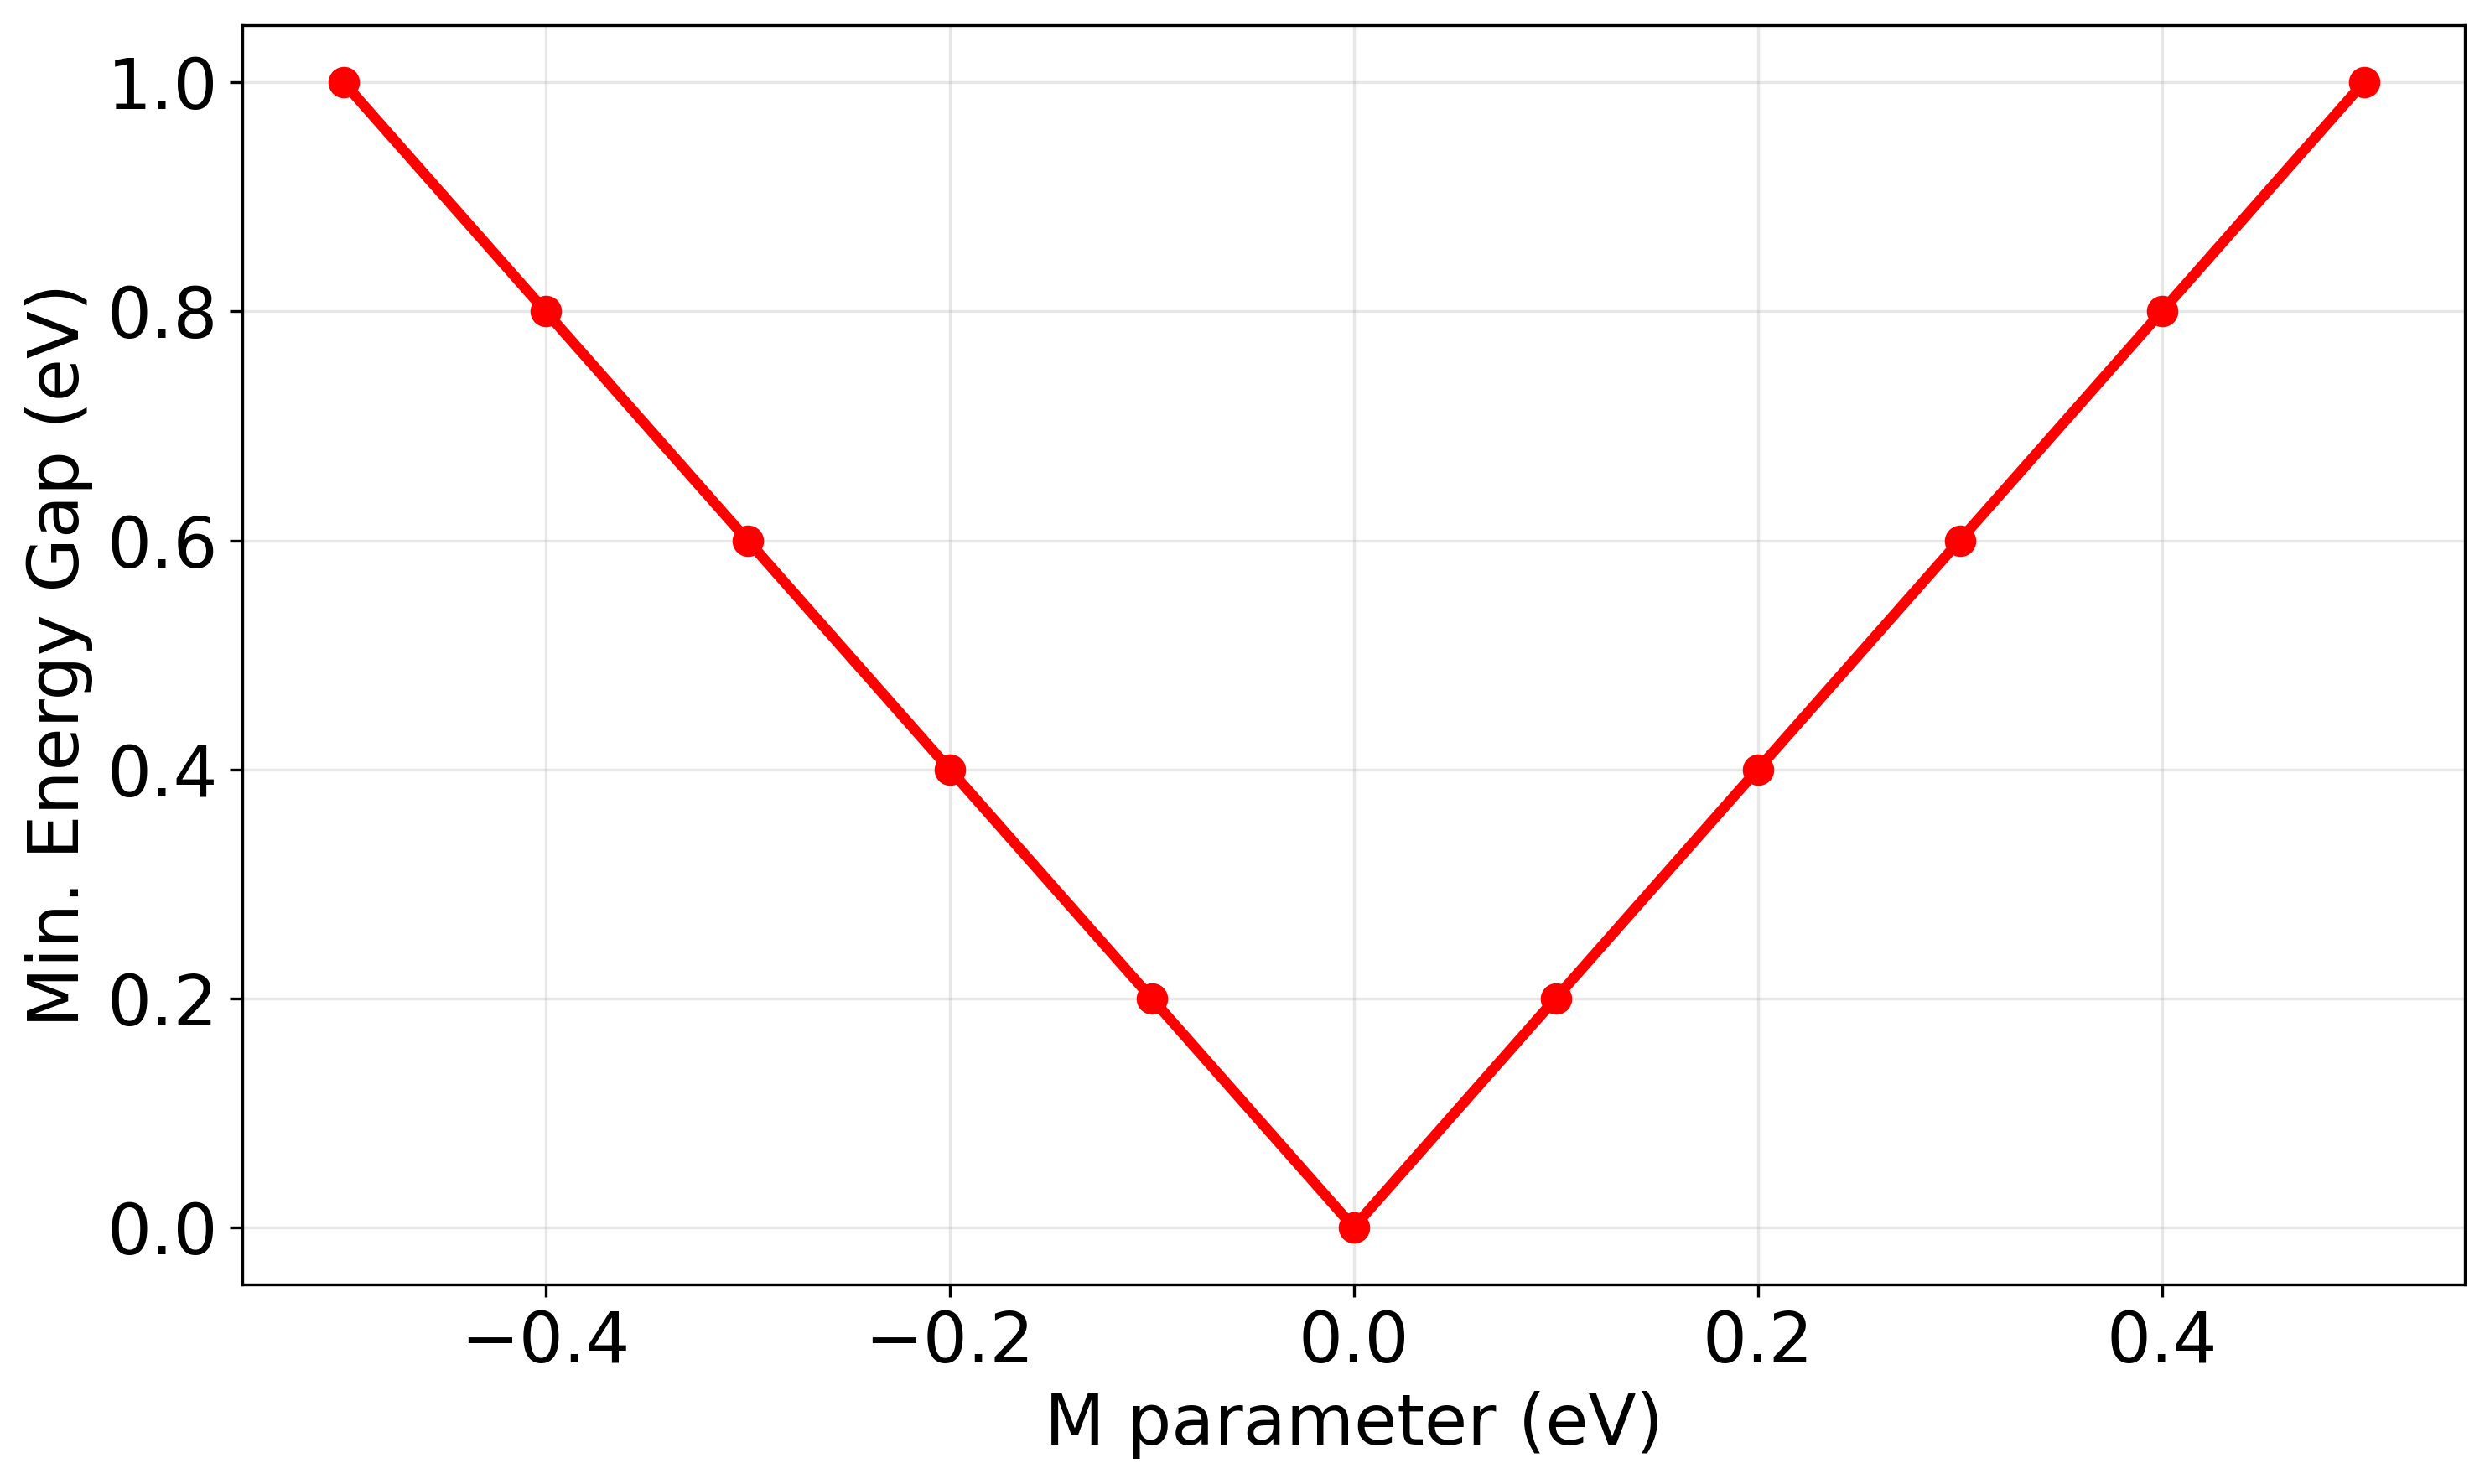

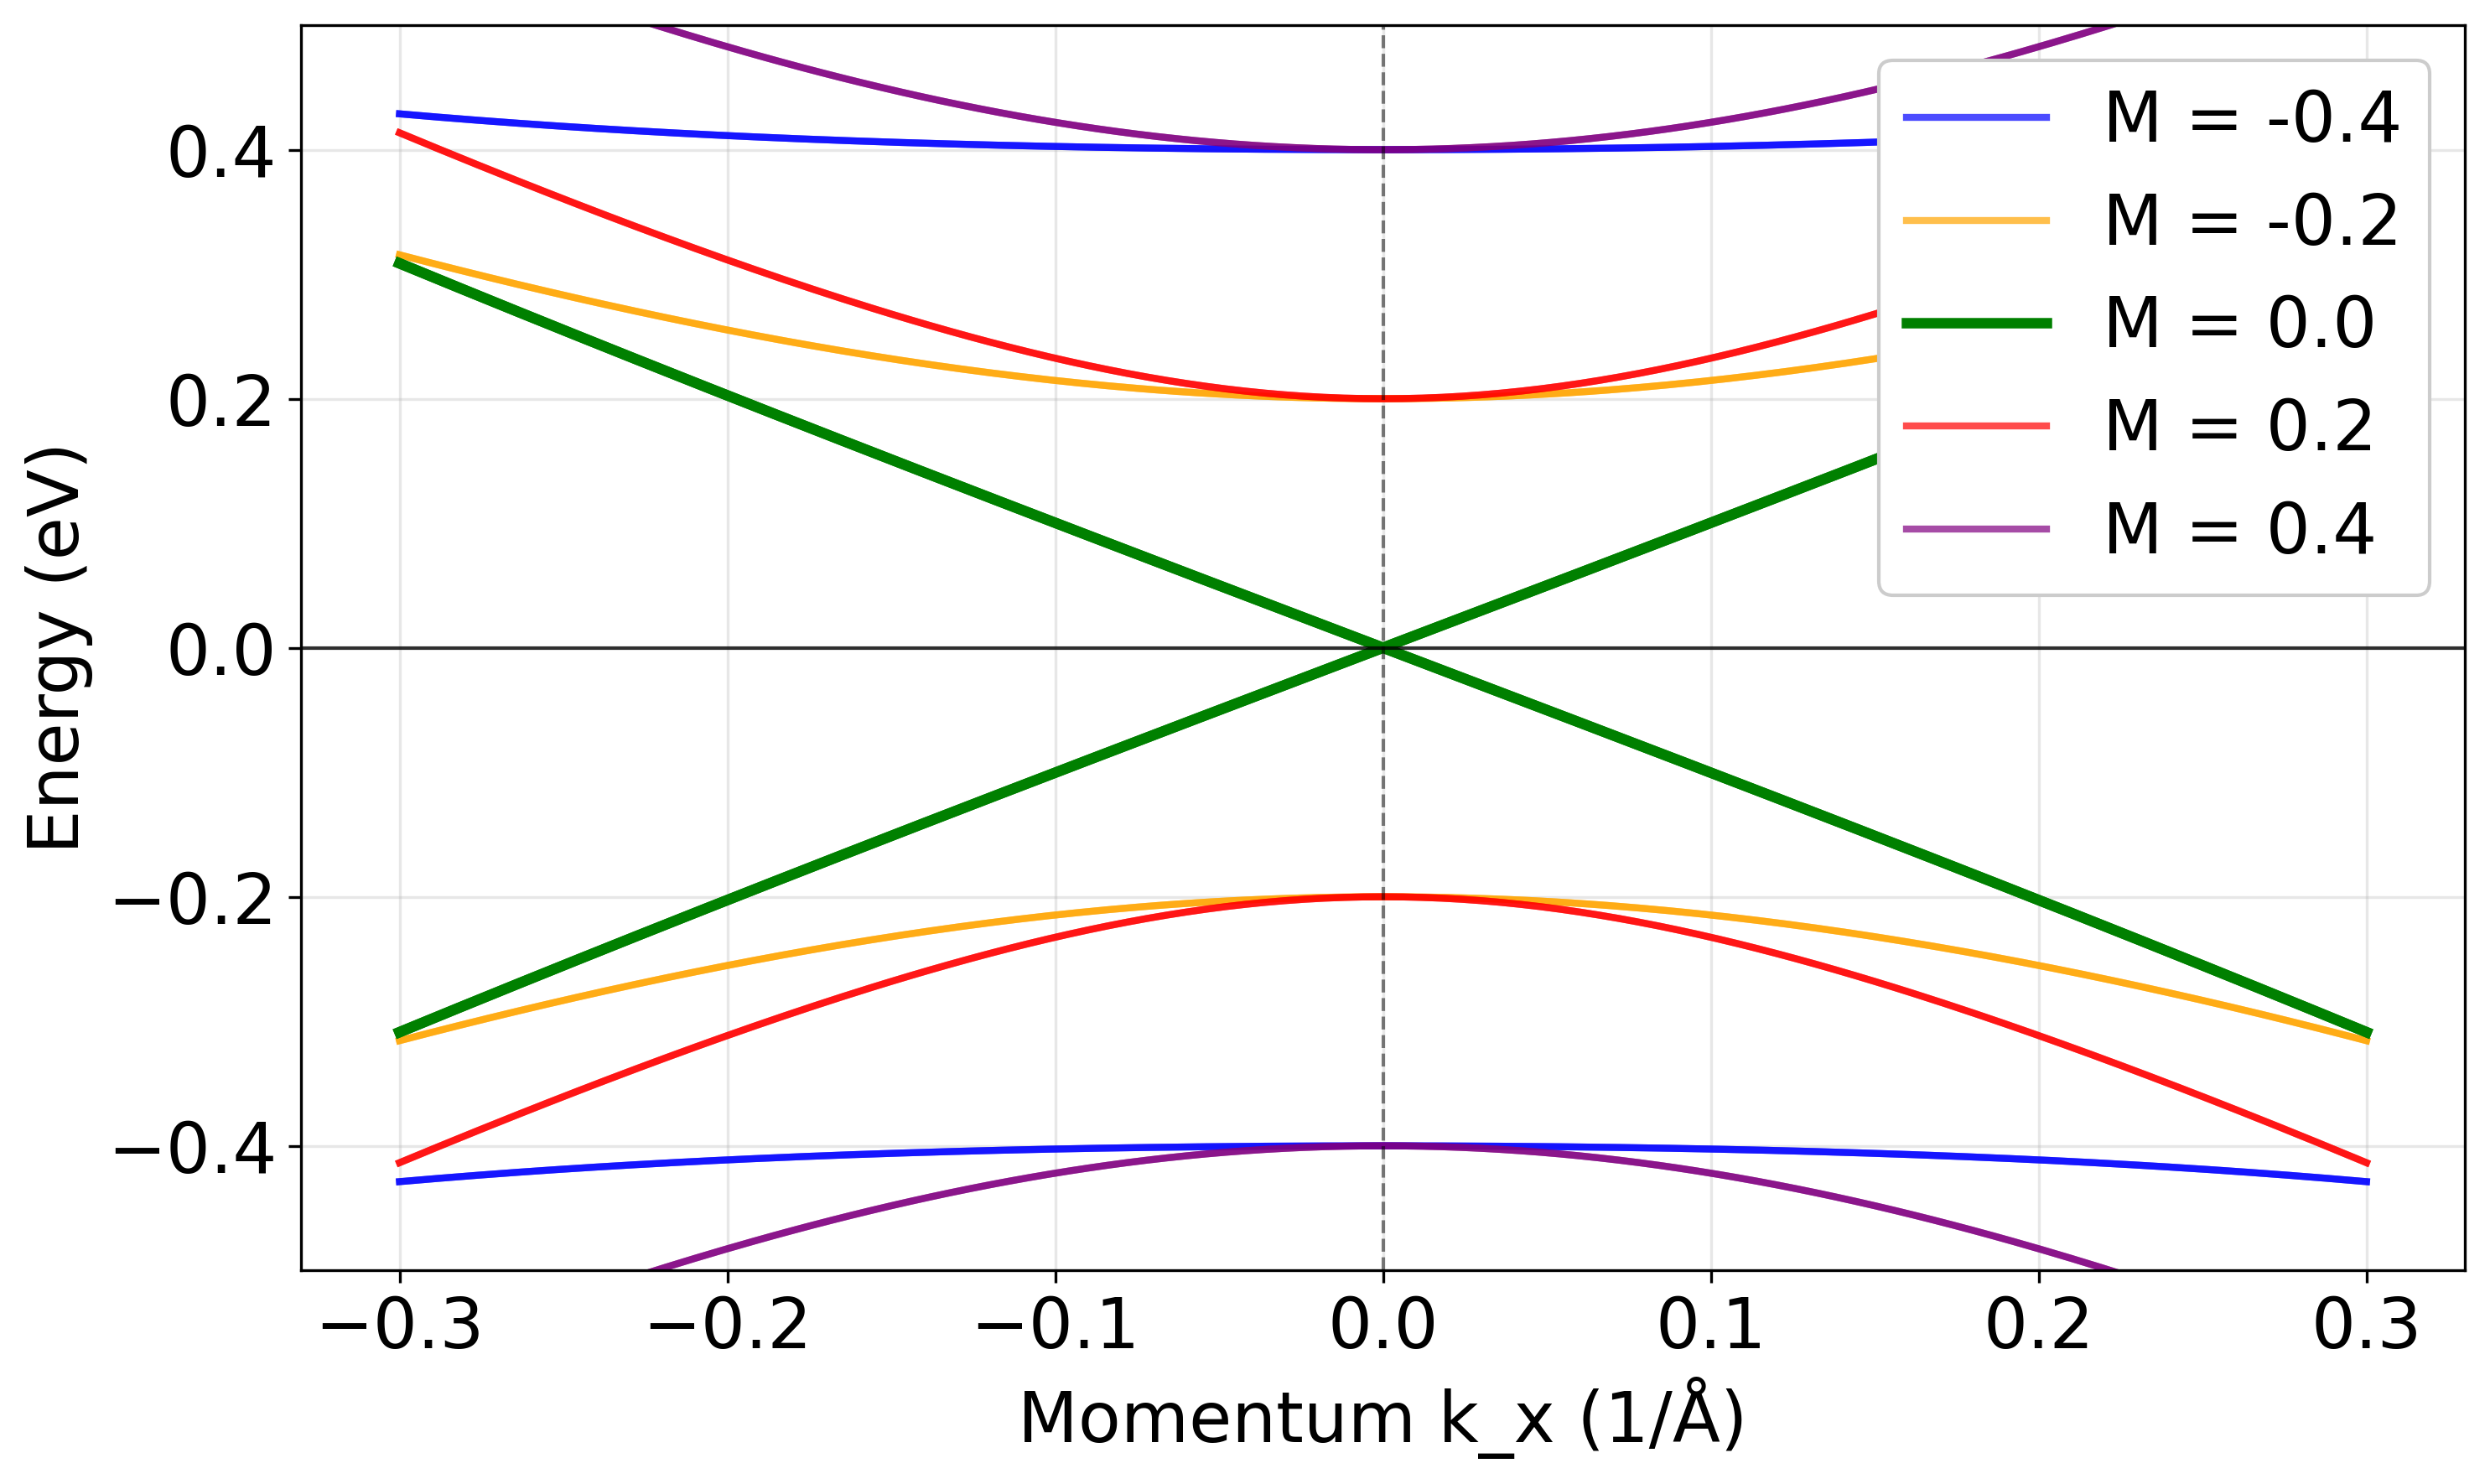

In [4]:
# Creating plots for band gap and dispersion
# Gap energy vs M
plt.figure(figsize=(10, 6),dpi=300)
plt.plot(M_values, gaps, 'o-', linewidth=3, markersize=8, color='red')
# plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
# plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.ylabel('Min. Energy Gap (eV)', fontsize=20)
plt.xlabel('M parameter (eV)', fontsize=20)
plt.tick_params(labelsize=20)

plt.tick_params(labelsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("parameter_m.pdf", bbox_inches='tight')
plt.show()

# Dispersion
plt.figure(figsize=(10, 6),dpi=300)

# Making the plots look pleasing
for i, M in enumerate(M_values_plot):
    bands = bands_data[i]
    alpha = 1.0 if M == 0.0 else 0.7  
    linewidth = 3 if M == 0.0 else 2
    
    # Plot all 4 bands for this M value
    for band in range(4):
        label = f'M = {M:.1f}' if band == 1 else ''  
        plt.plot(k_vals_1d, bands[:, band], color=colours[i], linewidth=linewidth, alpha=alpha, label=label)
        
plt.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
plt.ylabel('Energy (eV)', fontsize=20)
plt.xlabel('Momentum k_x (1/Å)', fontsize=20) #units 1/Å
plt.tick_params(labelsize=20)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=20, loc='upper right', framealpha=1)
plt.ylim(-0.5, 0.5)
plt.tight_layout()
plt.savefig("bulk_dispersion_legend.pdf", bbox_inches='tight')
plt.show()
